# Jones Digital Compiler

## Setup

Save this notebook as `exp.ipynb` in the cloned repository root. Python 3.10+ is required. The compiler repository is public under MIT licsence. 

```bash
git clone https://github.com/kerryzhou1024/jones-digital-compiler.git
cd jones-digital-compiler
```

Now we set up the python environment to run the notebook.
```bash
# macOS / Linux
python3 -m venv .venv
source .venv/bin/activate

# Windows PowerShell: py -m venv .venv
# Windows PowerShell: .venv\Scripts\Activate.ps1

python -m pip install --upgrade pip
python -m pip install -e ".[notebook]" pandas jupyterlab "qdk[qre]==1.30.0"
```

I tend to use vs code for running notebooks, but you can also use jupyter lab: 
```bash
jupyter lab exp.ipynb
```

## How to use it

In order to define a Jones Polynomial problem, we take a braid-word, closure type, the number of strands, and the root of unity $k$. 

Below we create a hopf link using `s_1^2`, (other forms are also accepted, such as `1 1`) with trace closure. 

You can evaluate it via the `.evaluate()` function for the `JonesProblem` object. You can also run sampled evaluation (taking shots than statevector simulation of the circuits). The sampled evaluation is what we would run the experiment in real life, though it is subject to shot-based statistical noise. 

`.reference_value()` is computed via the AJL math as a dense matrix. It is hard-coded and not run from the compiled quantum circuits. For analytically deriven value with Kauffman brakets, we test them in pytest for 6 small cases (unknot, hopf link, trefoil, solomon link, figure-eight knot, borromean rings). 

In [1]:
from digital_compiler import JonesProblem

hopf = JonesProblem("s1^2", closure="trace", strands=2, k=5)
exact = hopf.evaluate()
sampled = hopf.evaluate(method="shots", shots=1_024, seed=7)
reference = hopf.reference_value()

assert abs(exact.value - reference) < 1e-9
{"exact": exact.value, "seeded shots": sampled.value, "reference": reference}

{'exact': (-0.19098300562505197-0.5877852522924727j),
 'seeded shots': (-0.2524938190854541-0.5725621648667236j),
 'reference': (-0.19098300562505194-0.5877852522924734j)}

The circuits are constructed lazily, meaning that unless they are needed, they are not pre-calculated to save on resources. 

With a Jones Problem defined, you can also create individual circuits and inspect them. For a well-defined Hadamard test circuit, it should have the initial path (usually `101010..10`), real or imaginary, and circuit level. 

The circuits can be printed with `.display()` method. Metadata can be obtained by calling `.info()`, this includes circuit parameters, gate counts table, nd compiler policy configuration. 

In [2]:
circuit = hopf.circuit(
    path="10", part="real", circuit_level=1, measure=True
)
circuit.display(max_lines=None)
circuit.info()

field,value
word,sigma_1 sigma_1
closure,trace
path,|10>
component,real
compiler level,1
strands / k,2 / 5
logical qubits,5
classical bits,1
quantum gates,5
quantum gate depth,4


You can also view level 3 circuit:

In [3]:
circuit = hopf.circuit(
    path="10", part="real", circuit_level=3, measure=True
)
circuit.display(max_lines=None)
circuit.info()

field,value
word,sigma_1 sigma_1
closure,trace
path,|10>
component,real
compiler level,3
strands / k,2 / 5
logical qubits,5
classical bits,1
quantum gates,57
quantum gate depth,49


We can also customize policies to compare different compiling strategies. 

In [4]:
from digital_compiler import (
    CommutingLayerScheduling,
    CompilerConfig,
    SerialGeneratorScheduling,
    compare_circuits,
)

word = "1 3 2 5"
path = "101010"



# We customize compiler config, and then pass in as a parameter that defines a jones problem. 

c1 = CompilerConfig(scheduling=SerialGeneratorScheduling())
c2 = CompilerConfig(scheduling=CommutingLayerScheduling(max_lanes=None))

j1 = JonesProblem(word, strands=6, k=5, closure="trace", config=c1)
j2 = JonesProblem(word, strands=6, k=5, closure="trace", config=c2)

policy_configs = {
    "serial word order": c1,
    "parallel commuting": c2,
}

policy_circuits = {
    "serial word order": j1.circuit(
        path=path, part="real", circuit_level=3, measure=False
    ),
    "parallel commuting": j2.circuit(
        path=path, part="real", circuit_level=3, measure=False
    ),
}

for label, compiled in policy_circuits.items():
    print(
        f"{label:<20} layers={compiled.metadata['generator_layers']} "
        f"active lanes={compiled.metadata['parallel_lanes']}"
    )


# This function in the digital_compiler module compares the circuits in great details
compare_circuits(policy_circuits)

serial word order    layers=((1,), (3,), (2,), (5,)) active lanes=1
parallel commuting   layers=((1, 3, 5), (2,)) active lanes=3


resource,serial word order,parallel commuting
word,sigma_1 sigma_3 sigma_2 sigma_5,sigma_1 sigma_3 sigma_2 sigma_5
closure,trace,trace
path,|101010>,|101010>
component,real,real
compiler level,3,3
logical qubits,9,13
classical bits,1,1
quantum gates,131,134
quantum gate depth,100,65
Qiskit circuit depth,100,65


In [5]:
j2.circuit(
        path=path, part="real", circuit_level=1, measure=False
    ).display(max_lines=None)

## Part 2: graphs and misc

### Scaling for 1 2 3 4 5..1 2 3 4..

In [6]:
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter
from digital_compiler import (
    CommutingLayerScheduling,
    CompilerConfig,
    TreeControlFanout,
)

def repeated_word(n, m):
    return " ".join(str(step % (n - 1) + 1) for step in range(m))


N_VALUES = tuple(range(2, 11))
M_VALUES = tuple(range(41))
scaling_rows = []

for n in N_VALUES:
    for m in M_VALUES:
        circuit = JonesProblem(
            repeated_word(n, m), strands=n, k=5, closure="trace"
        ).circuit(part="real", circuit_level=3, measure=False)
        info = circuit.info()
        route_steps = circuit.metadata["prefix_height_path_steps"]
        if m == 0:
            expected = (ceil(n / 2) + 2, 2, 0)
        else:
            q = ceil(m / (n - 1))
            expected = (
                2 + ceil(n / 2) + 27 * m + 3 * route_steps,
                1 + 24 * m + (0 if n == 2 else (2 * n - 5) * (q - 1)),
                (m - q) + (q - 1) * (n - 2),
            )
        observed = (info.quantum_gate_count, info.quantum_gate_depth, route_steps)
        assert observed == expected
        scaling_rows.append(
            {
                "n": n,
                "m": m,
                "gate_count": observed[0],
                "gate_depth": observed[1],
                "route_steps": observed[2],
            }
        )

scaling = pd.DataFrame(scaling_rows)
assert len(scaling) == 369

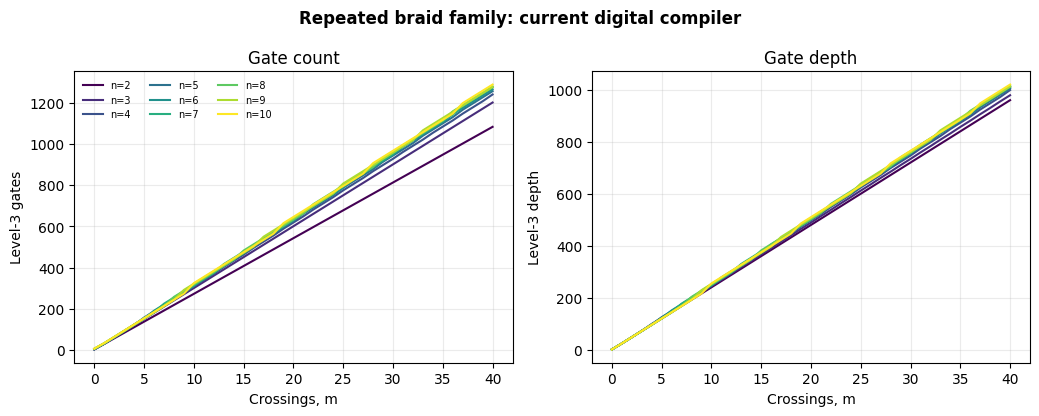

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
colors = plt.get_cmap("viridis")

for offset, n in enumerate(N_VALUES):
    selected = scaling[scaling["n"] == n]
    color = colors(offset / 8)
    axes[0].plot(
        selected["m"], selected["gate_count"], color=color, label=f"n={n}"
    )
    axes[1].plot(selected["m"], selected["gate_depth"], color=color)

for axis, title, ylabel in zip(
    axes,
    ("Gate count", "Gate depth"),
    ("Level-3 gates", "Level-3 depth"),
):
    axis.set(title=title, xlabel="Crossings, m", ylabel=ylabel)
    axis.grid(alpha=0.25)

axes[0].legend(ncols=3, fontsize=7, frameon=False)
fig.suptitle("Repeated braid family: current digital compiler", weight="bold")
fig.tight_layout()
plt.show()

### Digital and analog scaling

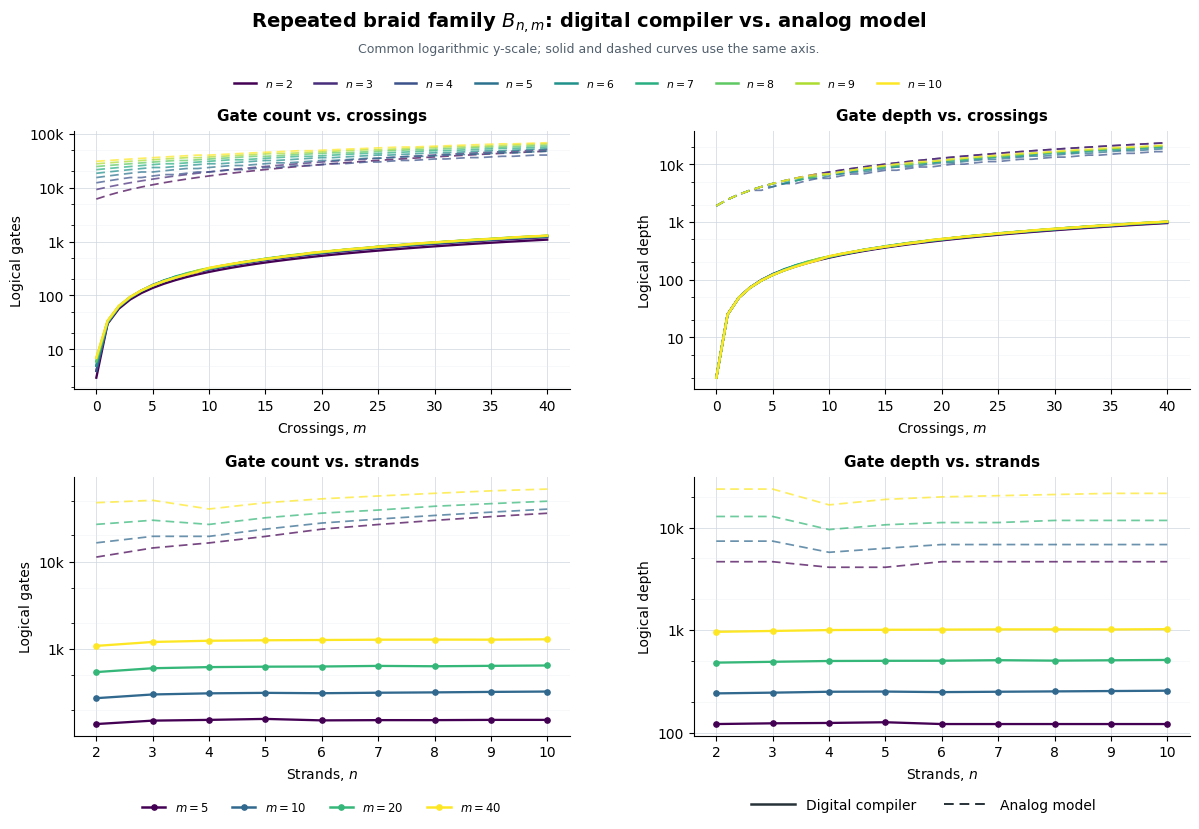

In [8]:
def analog_braid_depth(n, m):
    if m == 0 or n <= 3:
        return m
    return m - ceil(m / (n - 1)) + 1

# Change the formula here to match the lastest analog case
def analog_resources(n, m):
    braid_depth = analog_braid_depth(n, m)
    return {
        "gate_count": 1027 * braid_depth + 3060 * n,
        "gate_depth": 546 * braid_depth + 1916,
    }


SELECTED_M = (5, 10, 20, 40)
color_map = plt.get_cmap("viridis")
fig, axes = plt.subplots(2, 2, figsize=(12.4, 8.4))

for offset, n in enumerate(N_VALUES):
    selected = [row for row in scaling_rows if row["n"] == n]
    color = color_map(offset / (len(N_VALUES) - 1))
    crossings = [row["m"] for row in selected]
    analog = [analog_resources(n, m) for m in crossings]
    axes[0, 0].plot(
        crossings,
        [row["gate_count"] for row in selected],
        color=color,
        linewidth=1.65,
    )
    axes[0, 0].plot(
        crossings,
        [row["gate_count"] for row in analog],
        color=color,
        linestyle=(0, (5, 3)),
        linewidth=1.25,
        alpha=0.72,
    )
    axes[0, 1].plot(
        crossings,
        [row["gate_depth"] for row in selected],
        color=color,
        linewidth=1.65,
    )
    axes[0, 1].plot(
        crossings,
        [row["gate_depth"] for row in analog],
        color=color,
        linestyle=(0, (5, 3)),
        linewidth=1.25,
        alpha=0.72,
    )

for offset, m in enumerate(SELECTED_M):
    selected = [row for row in scaling_rows if row["m"] == m]
    color = color_map(offset / (len(SELECTED_M) - 1))
    strands = [row["n"] for row in selected]
    analog = [analog_resources(n, m) for n in strands]
    axes[1, 0].plot(
        strands,
        [row["gate_count"] for row in selected],
        marker="o",
        markersize=3.8,
        color=color,
        linewidth=1.65,
    )
    axes[1, 0].plot(
        strands,
        [row["gate_count"] for row in analog],
        color=color,
        linestyle=(0, (5, 3)),
        linewidth=1.25,
        alpha=0.72,
    )
    axes[1, 1].plot(
        strands,
        [row["gate_depth"] for row in selected],
        marker="o",
        markersize=3.8,
        color=color,
        linewidth=1.65,
    )
    axes[1, 1].plot(
        strands,
        [row["gate_depth"] for row in analog],
        color=color,
        linestyle=(0, (5, 3)),
        linewidth=1.25,
        alpha=0.72,
    )


def compact_log_tick(value, _position):
    return f"{value / 1000:g}k" if value >= 1000 else f"{value:g}"


for axis, title, x_label, y_label in (
    (axes[0, 0], "Gate count vs. crossings", r"Crossings, $m$", "Logical gates"),
    (axes[0, 1], "Gate depth vs. crossings", r"Crossings, $m$", "Logical depth"),
    (axes[1, 0], "Gate count vs. strands", r"Strands, $n$", "Logical gates"),
    (axes[1, 1], "Gate depth vs. strands", r"Strands, $n$", "Logical depth"),
):
    axis.set_title(title, fontsize=11, fontweight="bold", pad=8)
    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.set_yscale("log")
    axis.yaxis.set_major_locator(LogLocator(base=10))
    axis.yaxis.set_major_formatter(FuncFormatter(compact_log_tick))
    axis.yaxis.set_minor_locator(LogLocator(base=10, subs=(2, 5)))
    axis.yaxis.set_minor_formatter(NullFormatter())
    axis.grid(which="major", color="#cfd6df", linewidth=0.7, alpha=0.72)
    axis.grid(which="minor", color="#e7ebf0", linewidth=0.45, alpha=0.55)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

strand_legend = tuple(
    Line2D(
        [],
        [],
        color=color_map(offset / (len(N_VALUES) - 1)),
        linewidth=1.8,
        label=fr"$n={n}$",
    )
    for offset, n in enumerate(N_VALUES)
)
crossing_legend = tuple(
    Line2D(
        [],
        [],
        color=color_map(offset / (len(SELECTED_M) - 1)),
        marker="o",
        markersize=3.8,
        linewidth=1.8,
        label=fr"$m={m}$",
    )
    for offset, m in enumerate(SELECTED_M)
)
style_legend = (
    Line2D([], [], color="#263238", linewidth=1.8, label="Digital compiler"),
    Line2D(
        [],
        [],
        color="#263238",
        linewidth=1.4,
        linestyle=(0, (5, 3)),
        label="Analog model",
    ),
)
fig.legend(
    handles=strand_legend,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.916),
    ncol=len(N_VALUES),
    frameon=False,
    fontsize=7.8,
)
fig.legend(
    handles=crossing_legend,
    loc="lower center",
    bbox_to_anchor=(0.285, 0.014),
    ncol=len(SELECTED_M),
    frameon=False,
    fontsize=8.4,
)
fig.legend(
    handles=style_legend,
    loc="lower center",
    bbox_to_anchor=(0.77, 0.014),
    ncol=2,
    frameon=False,
    handlelength=3.2,
)
fig.suptitle(
    r"Repeated braid family $B_{n,m}$: digital compiler vs. analog model",
    fontsize=14,
    fontweight="bold",
    y=0.985,
)
fig.text(
    0.5,
    0.946,
    "Common logarithmic y-scale; solid and dashed curves use the same axis.",
    ha="center",
    va="top",
    fontsize=9,
    color="#52606d",
)
fig.subplots_adjust(
    left=0.085,
    right=0.985,
    top=0.84,
    bottom=0.12,
    hspace=0.34,
    wspace=0.25,
)
plt.show()

### Parallelization graph

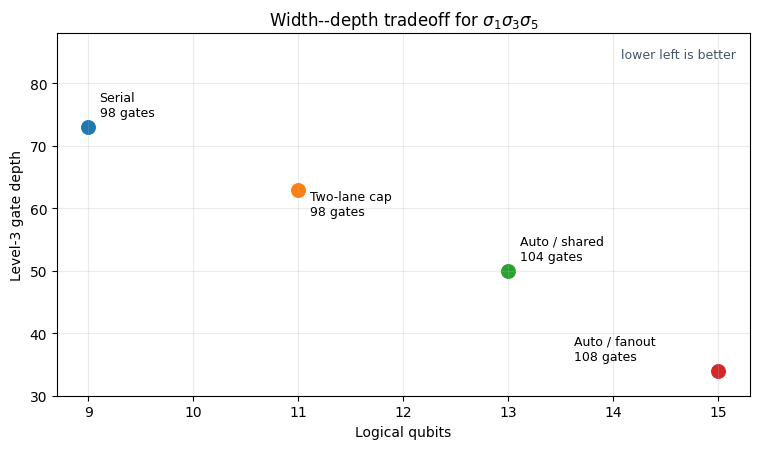

In [9]:
# change word here to see different results
word = "1 3 5"

parallel_configs = {
    "Serial": CompilerConfig(),
    "Two-lane cap": CompilerConfig(
        scheduling=CommutingLayerScheduling(max_lanes=2)
    ),
    "Auto / shared": CompilerConfig(scheduling=CommutingLayerScheduling()),
    "Auto / fanout": CompilerConfig(
        scheduling=CommutingLayerScheduling(),
        control_distribution=TreeControlFanout(),
    ),
}
parallel_rows = []

for label, config in parallel_configs.items():
    circuit = JonesProblem(word, strands=6, k=5, config=config).circuit(
        path="101010", part="real", circuit_level=3, measure=False
    )
    info = circuit.info()
    parallel_rows.append(
        {
            "schedule": label,
            "logical qubits": info.logical_qubits,
            "quantum gates": info.quantum_gate_count,
            "quantum depth": info.quantum_gate_depth,
        }
    )

parallel = pd.DataFrame(parallel_rows)
fig, ax = plt.subplots(figsize=(7.7, 4.6))
offsets = ((8, 8), (8, -18), (8, 8), (-104, 8))

for row, offset in zip(parallel.to_dict("records"), offsets):
    ax.scatter(row["logical qubits"], row["quantum depth"], s=95)
    ax.annotate(
        f'{row["schedule"]}\n{row["quantum gates"]} gates',
        (row["logical qubits"], row["quantum depth"]),
        xytext=offset,
        textcoords="offset points",
        fontsize=9,
    )

ax.set(
    xlabel="Logical qubits",
    ylabel="Level-3 gate depth",
    title=r"Width--depth tradeoff for $\sigma_1\sigma_3\sigma_5$",
)
ax.set_ylim(30, 88)
ax.text(
    0.98,
    0.96,
    "lower left is better",
    ha="right",
    va="top",
    transform=ax.transAxes,
    fontsize=9,
    color="#475569",
)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### Microsoft Quantum Resource Estimator

In [10]:
from importlib.metadata import version
import re
import tempfile

from digital_compiler import CliffordTConfig
from qiskit import qasm3
from qdk.qre import estimate, property_name
from qdk.qre.application import OpenQASMApplication
from qdk.qre.models import GateBased, RoundBasedFactory, SurfaceCode

assert version("qdk") == "1.30.0"

SYNTHESIS_ERROR_BUDGET = 1e-3
PHYSICAL_ERROR_RATE = 1e-3
GATE_TIME_NS = 1_000
MEASUREMENT_TIME_NS = 1_000
MAX_EXECUTION_ERROR = 0.01

qre_config = CompilerConfig(
    level4=CliffordTConfig(
        synthesis_error_budget=SYNTHESIS_ERROR_BUDGET,
    )
)
architecture = GateBased(
    error_rate=PHYSICAL_ERROR_RATE,
    gate_time=GATE_TIME_NS,
    measurement_time=MEASUREMENT_TIME_NS,
)
surface_code = SurfaceCode.q() * RoundBasedFactory.q(
    cache_dir=Path(tempfile.gettempdir()) / "jones-qdk-cache"
)
zero_register = re.compile(r"\s*(?:bit|qubit)\[0\]\s+\w+;\s*")

In [11]:
def compile_case(case):
    problem = JonesProblem(
        case["braid"],
        strands=case["strands"],
        closure="trace",
        config=qre_config,
        k=5,
    )
    compiled = problem.circuit(
        case["path"],
        "real",
        circuit_level=4,
        measure=True,
    )
    return compiled


def openqasm_application(compiled):
    qasm_source = "\n".join(
        line
        for line in qasm3.dumps(compiled.circuit).splitlines()
        if zero_register.fullmatch(line) is None
    ) + "\n"
    return OpenQASMApplication(qasm_source)


def estimate_frontier(case, compiled):
    results = estimate(
        openqasm_application(compiled),
        architecture,
        surface_code,
        max_error=MAX_EXECUTION_ERROR,
        name=case["slug"],
    )
    rows = []
    for entry in results:
        properties = {
            property_name(key): value for key, value in entry.properties.items()
        }
        factories = list(entry.factories.values())
        rows.append(
            {
                "link": case["name"],
                "physical qubits": int(entry.qubits),
                "runtime (ms)": entry.runtime / 1e6,
                "estimated failure": float(entry.error),
                "compute qubits": int(properties["PHYSICAL_COMPUTE_QUBITS"]),
                "factory qubits": int(properties["PHYSICAL_FACTORY_QUBITS"]),
                "factory copies": sum(factory.copies for factory in factories),
                "T states": sum(factory.states for factory in factories),
            }
        )
    return pd.DataFrame(rows).sort_values("physical qubits").reset_index(drop=True)

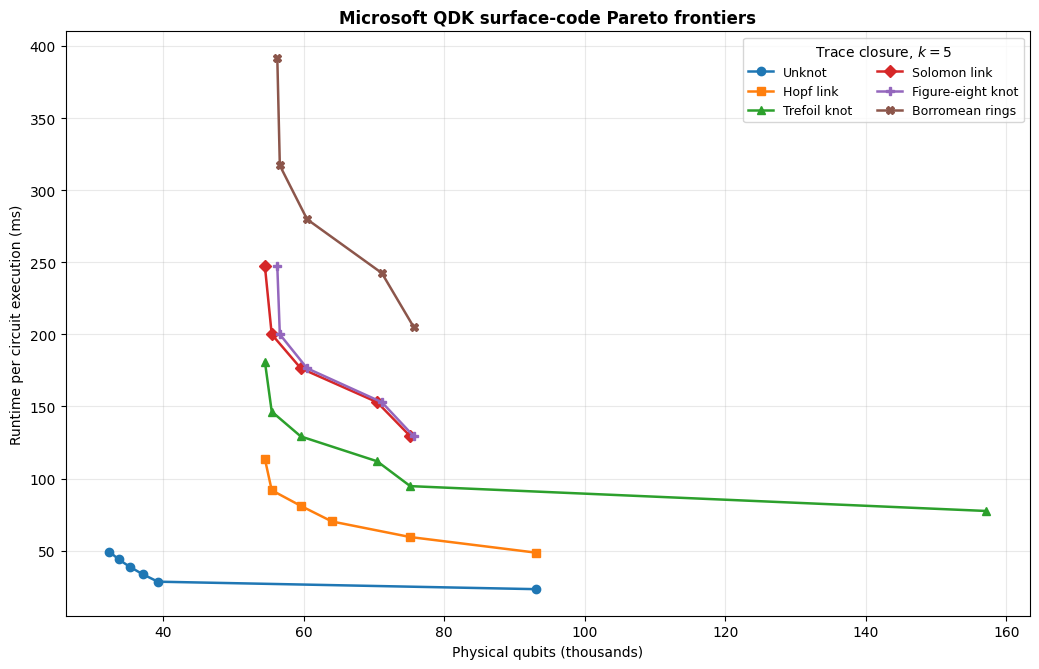

In [12]:
LINK_CASES = [
    {
        "name": "Unknot",
        "slug": "unknot",
        "braid": "s1",
        "strands": 2,
        "path": "10",
    },
    {
        "name": "Hopf link",
        "slug": "hopf_link",
        "braid": "s1^2",
        "strands": 2,
        "path": "10",
    },
    {
        "name": "Trefoil knot",
        "slug": "trefoil_knot",
        "braid": "s1^3",
        "strands": 2,
        "path": "10",
    },
    {
        "name": "Solomon link",
        "slug": "solomon_link",
        "braid": "s1^4",
        "strands": 2,
        "path": "10",
    },
    {
        "name": "Figure-eight knot",
        "slug": "figure_eight_knot",
        "braid": "s1 -2 s1 -2",
        "strands": 3,
        "path": "101",
    },
    {
        "name": "Borromean rings",
        "slug": "borromean_rings",
        "braid": "s1 -2 s1 -2 s1 -2",
        "strands": 3,
        "path": "101",
    },
]

frontiers = {}
for case in LINK_CASES:
    compiled = compile_case(case)
    frontiers[case["name"]] = estimate_frontier(case, compiled)

colors = plt.get_cmap("tab10").colors
markers = ("o", "s", "^", "D", "P", "X")
fig, ax = plt.subplots(figsize=(10.5, 6.8))

for index, case in enumerate(LINK_CASES):
    frontier = frontiers[case["name"]]
    ax.plot(
        frontier["physical qubits"] / 1_000,
        frontier["runtime (ms)"],
        color=colors[index],
        marker=markers[index],
        markersize=6,
        linewidth=1.8,
        label=case["name"],
    )

ax.set_title("Microsoft QDK surface-code Pareto frontiers", weight="bold")
ax.set_xlabel("Physical qubits (thousands)")
ax.set_ylabel("Runtime per circuit execution (ms)")
ax.grid(True, alpha=0.28)
ax.legend(title=r"Trace closure, $k=5$", ncols=2, frameon=True, fontsize=9)
fig.tight_layout()
plt.show()